# Telco Customer Churn — Business Analysis

## Objective

The goal of this notebook is to analyze customer churn behavior and identify the customer segments with the highest risk of leaving.

This business analysis focuses on answering the following questions:

- What is the overall churn rate?
- Which customer groups churn the most?
- How do services, billing behavior, and tenure affect churn?
- What business actions could help improve retention?

This notebook is designed to support business decision-making by identifying practical churn patterns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load Dataset

In this section, we load the Telco Customer Churn dataset and inspect its structure.


In [3]:
df = pd.read_csv("../data/telco_churn_cleaned.csv")

## Initial Inspection

We first check the size of the dataset, column names, and data types.

In [4]:
print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n")
df.info()

Dataset shape: (7032, 24)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Flag', 'TenureGroup', 'MonthlyChargesGroup']

Data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   gender               7032 non-null   object 
 2   SeniorCitizen        7032 non-null   int64  
 3   Partner              7032 non-null   object 
 4   Dependents           7032 non-null   object 
 5   tenure               7032 non-null   int64  
 6   PhoneService         7032 non-null   object 
 7   MultipleLin

## Missing Values

We check whether any variables contain missing values.

In [5]:
df.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
Churn_Flag             0
TenureGroup            0
MonthlyChargesGroup    0
dtype: int64

## Feature Engineering

To make the analysis easier, we create a few helper variables:

- `Churn_Flag`: converts churn into binary format
- `TenureGroup`: groups customers by length of relationship
- `MonthlyChargesGroup`: groups customers by monthly charge level

In [6]:
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

df["MonthlyChargesGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,TenureGroup,MonthlyChargesGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,High


A churn rate close to 27% means that roughly 1 out of every 4 customers leaves the company.

This suggests a significant retention issue and makes churn reduction an important business priority.

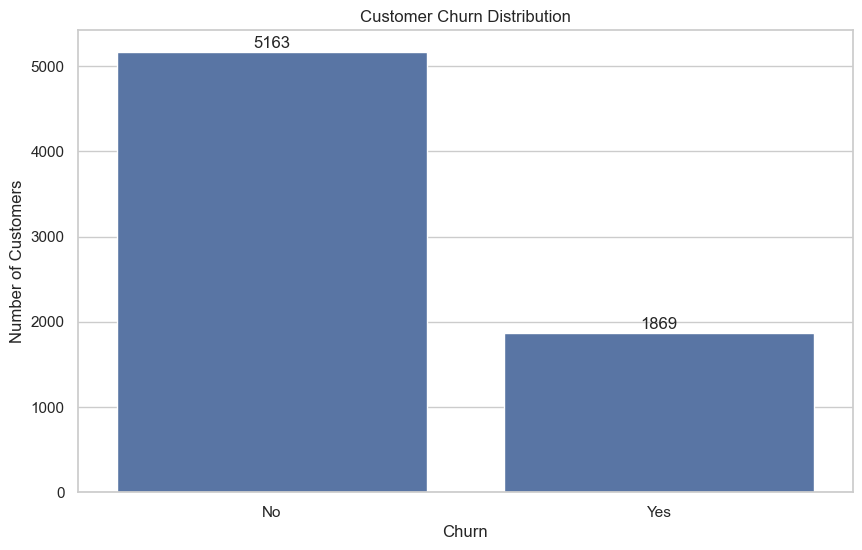

In [7]:
churn_counts = df["Churn"].value_counts()

ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 50, f"{value}", ha="center")

plt.show()

## Churn by Contract Type

Contract type is one of the most important customer behavior variables because it reflects commitment level.

We calculate churn rate by contract category instead of only counting customers.

In [8]:
contract_churn = (df.groupby("Contract")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
contract_churn

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn_Flag, dtype: float64

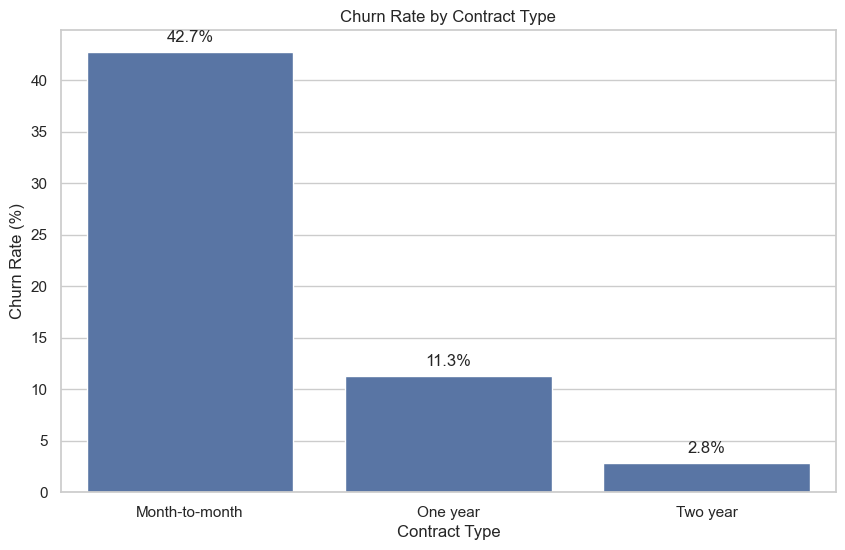

In [9]:
ax = sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(contract_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Month-to-month customers show by far the highest churn rate, while customers on one-year and two-year contracts are much more stable.

This suggests that longer contract commitment is strongly associated with better retention.

## Churn by Payment Method

Payment method may reveal customer habits and level of billing automation.

We examine whether certain payment methods are associated with higher churn.

In [10]:
payment_churn = (df.groupby("PaymentMethod")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn_Flag, dtype: float64

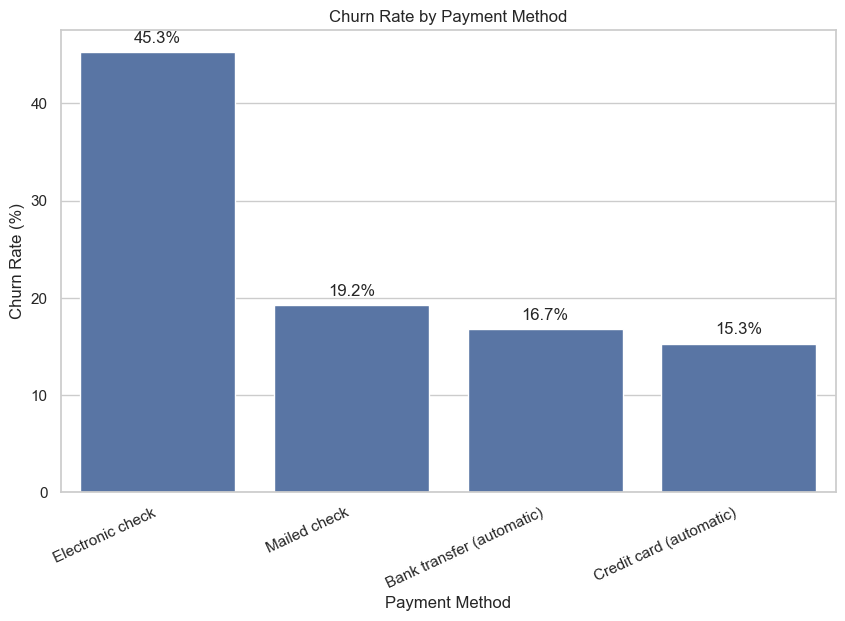

In [11]:
ax = sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")

for i, value in enumerate(payment_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers using electronic check have the highest churn rate among all payment methods.

In contrast, automatic payment methods such as bank transfer and credit card show lower churn.

This suggests that payment automation may be linked to stronger customer retention.

## Churn by Tenure Group

Customer tenure is critical because early-stage customers are often the most vulnerable to leaving.

To make the pattern easier to interpret, customers are grouped by tenure range.

In [12]:
tenure_churn = (
    df.groupby("TenureGroup", observed=False)["Churn_Flag"]
    .mean() * 100
).sort_values(ascending=False)

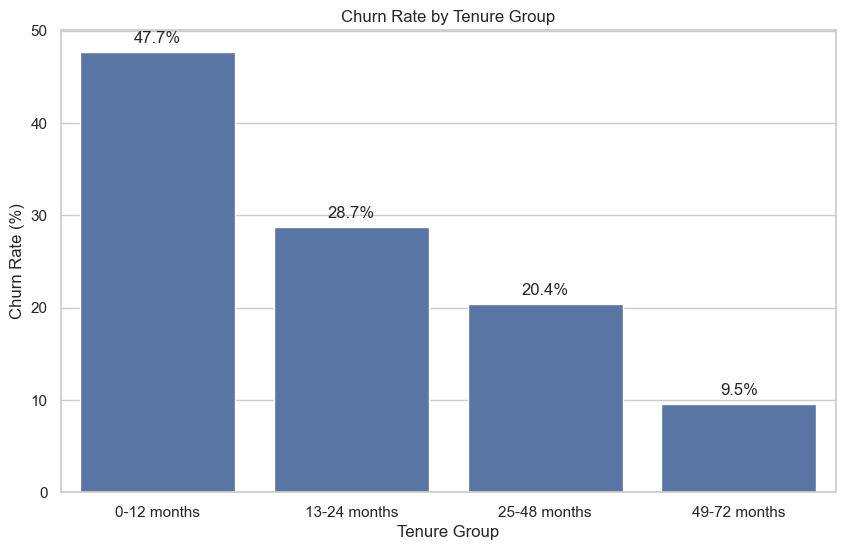

In [13]:
ax = sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(tenure_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers in their first 12 months churn the most, and churn decreases steadily as tenure increases.

This indicates that the early customer lifecycle is the most important period for retention efforts.

## Churn by Senior Citizen Status

We now examine whether churn behavior differs between senior citizens and non-senior customers.

In [14]:
senior_labels = {0: "No", 1: "Yes"}

senior_churn = (df.groupby("SeniorCitizen")["Churn_Flag"].mean() * 100)
senior_churn.index = senior_churn.index.map(senior_labels)
senior_churn = senior_churn.sort_values(ascending=False)

senior_churn

SeniorCitizen
Yes    41.681261
No     23.650255
Name: Churn_Flag, dtype: float64

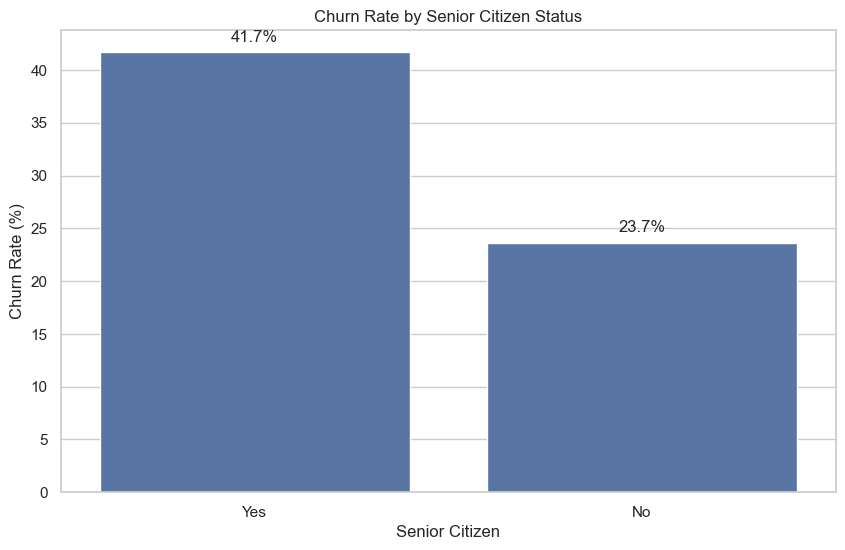

In [15]:
ax = sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(senior_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Senior citizens have a notably higher churn rate than non-senior customers.

This may indicate that older customers face different service expectations, pricing sensitivity, or support needs.

## Churn by Internet Service Type

Internet service type is often strongly linked to customer experience.

We analyze churn by service type to identify whether certain internet products are riskier than others.

In [16]:
internet_churn = (df.groupby("InternetService")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
internet_churn

InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn_Flag, dtype: float64

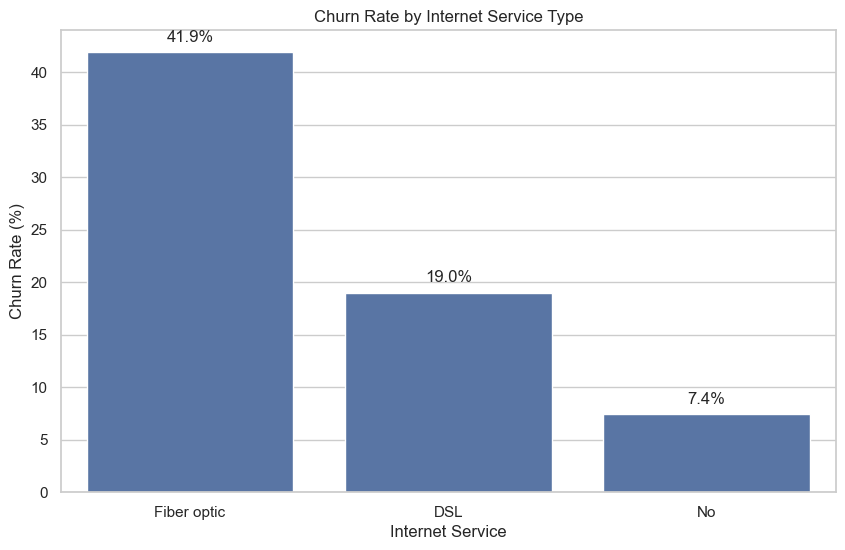

In [17]:
ax = sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(internet_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers with fiber optic internet show the highest churn, while customers without internet service churn the least.

This could suggest that fiber optic customers have higher expectations or experience issues related to price, quality, or competition.

## Churn by Online Security

Online security can increase the perceived value of the service bundle.

We examine whether customers with this feature are less likely to churn.

In [18]:
security_churn = (df.groupby("OnlineSecurity")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
security_churn

OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: Churn_Flag, dtype: float64

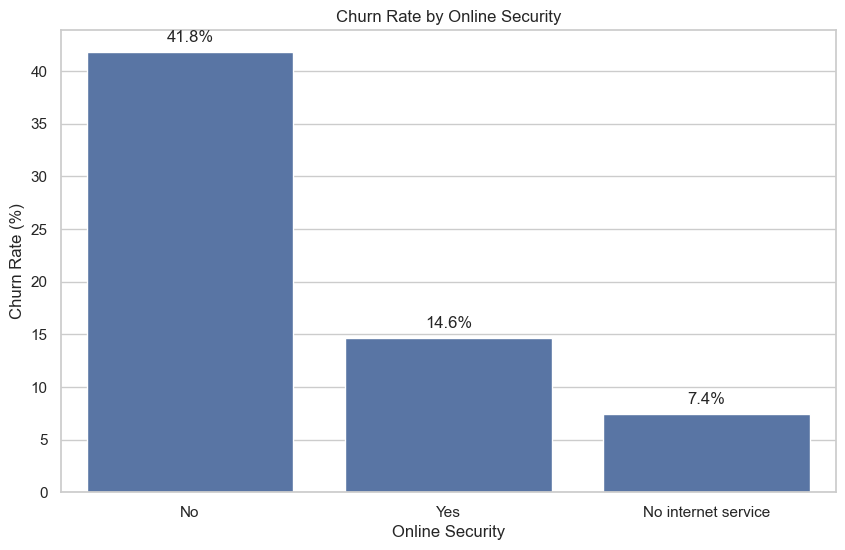

In [19]:
ax = sns.barplot(
    x=security_churn.index,
    y=security_churn.values
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(security_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers without online security churn much more than customers who have this service.

This suggests that bundled value-added services may improve customer stickiness and reduce churn risk.

## Churn by Tech Support

Technical support may play an important role in retention, especially for more demanding customers.

We compare churn rates across tech support categories.

In [20]:
techsupport_churn = (df.groupby("TechSupport")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
techsupport_churn

TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: Churn_Flag, dtype: float64

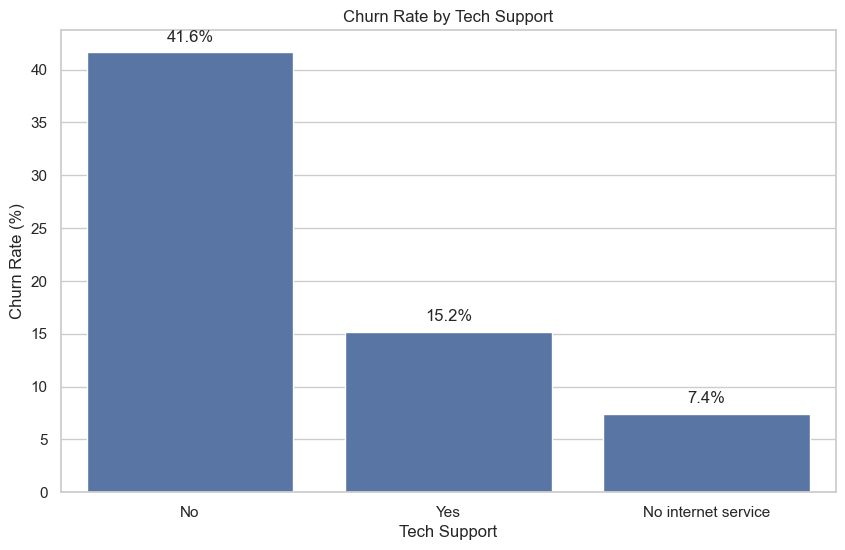

In [21]:
ax = sns.barplot(
    x=techsupport_churn.index,
    y=techsupport_churn.values
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(techsupport_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers without tech support have much higher churn rates than those who do have support.

This indicates that technical assistance may be an important retention lever, particularly for customers using more complex services.

## Churn by Paperless Billing

Billing behavior can also provide signals of customer risk.

We compare churn rate between customers with and without paperless billing.

In [22]:
paperless_churn = (df.groupby("PaperlessBilling")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
paperless_churn

PaperlessBilling
Yes    33.589251
No     16.375698
Name: Churn_Flag, dtype: float64

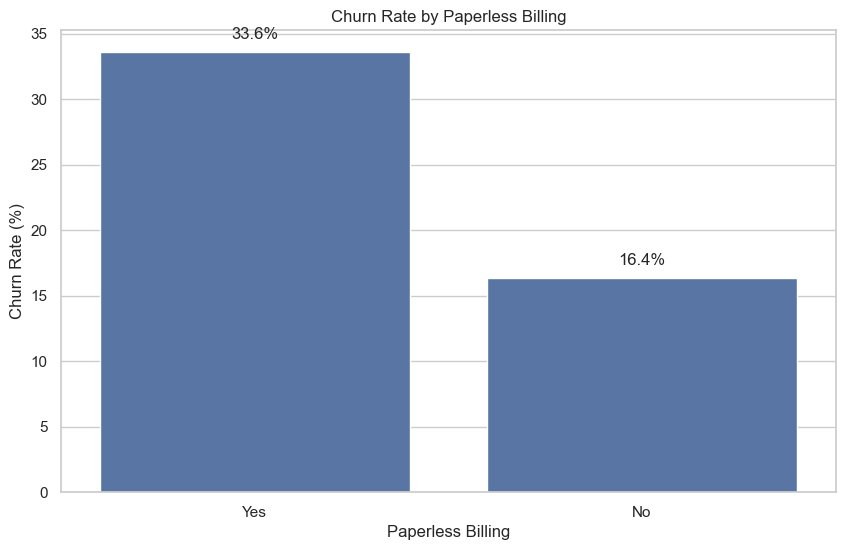

In [23]:
ax = sns.barplot(
    x=paperless_churn.index,
    y=paperless_churn.values
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(paperless_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers enrolled in paperless billing churn more than those who are not.

This does not necessarily mean paperless billing causes churn, but it may correlate with specific customer profiles or billing preferences.

## Churn by Monthly Charges

Price sensitivity is often a major driver of churn.

We group customers by monthly charge level to see whether higher-paying customers are more likely to leave.

In [30]:
monthly_churn = (
    df.groupby("MonthlyChargesGroup", observed=False)["Churn_Flag"]
    .mean() * 100
).sort_values(ascending=False)

In [31]:
monthly_churn = monthly_churn.reindex(["Low", "Medium", "High", "Very High"])
monthly_churn

MonthlyChargesGroup
Low          11.319681
Medium       24.588302
High         37.549858
Very High    32.878271
Name: Churn_Flag, dtype: float64

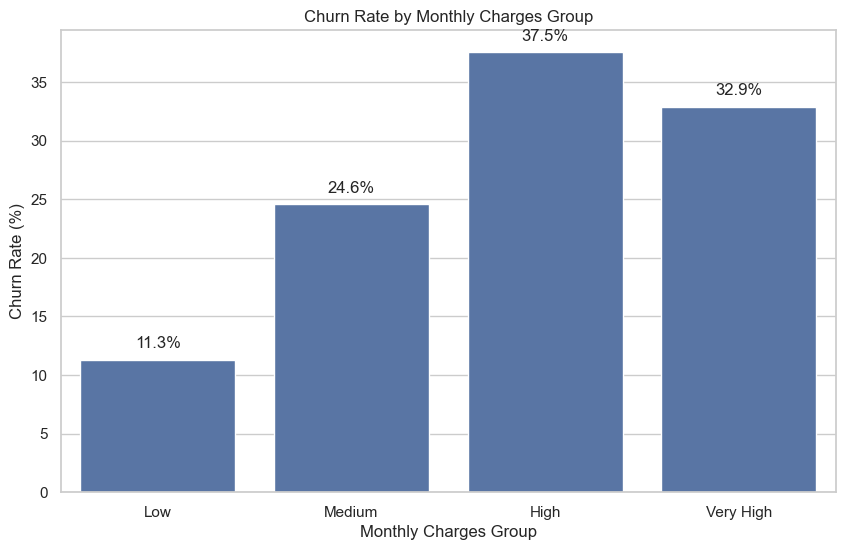

In [32]:
ax = sns.barplot(
    x=monthly_churn.index,
    y=monthly_churn.values
)

plt.title("Churn Rate by Monthly Charges Group")
plt.xlabel("Monthly Charges Group")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(monthly_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers in the higher monthly charge groups show higher churn than those in the low-charge group.

This suggests that pricing pressure or perceived value may affect retention, especially among higher-paying customers.

## Distribution of Monthly Charges by Churn Status

To complement the grouped analysis, we compare the distribution of monthly charges between churned and retained customers.

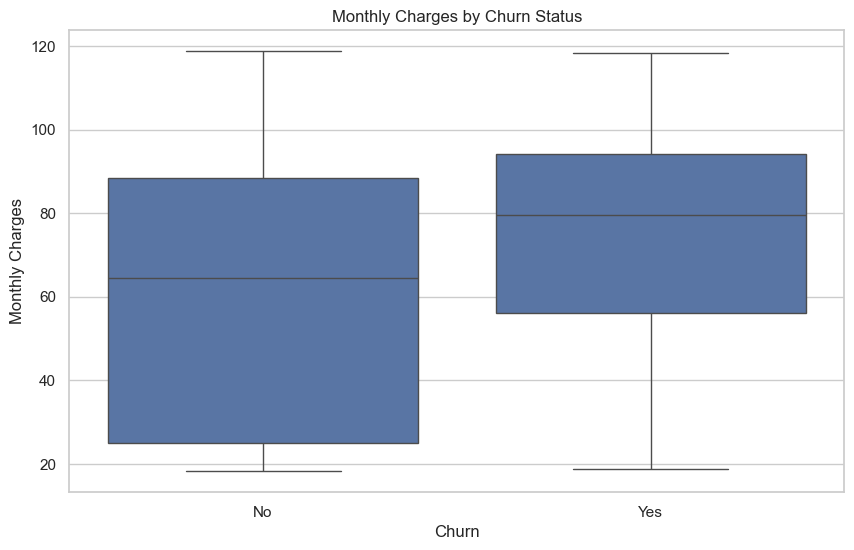

In [33]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

The boxplot helps visualize whether churned customers tend to have higher monthly charges than retained customers.

This adds support to the idea that pricing or service-value perception may contribute to cancellation.

## Top Risk Segments Summary

Now we summarize the highest-risk groups identified across the analysis.

In [34]:
risk_summary = pd.DataFrame({
    "Segment": [
        "Month-to-month contract",
        "Electronic check",
        "0-12 months tenure",
        "Senior citizen",
        "Fiber optic",
        "No online security",
        "No tech support",
        "High monthly charges"
    ],
    "Churn Rate (%)": [
        contract_churn.loc["Month-to-month"],
        payment_churn.loc["Electronic check"],
        tenure_churn.loc["0-12 months"],
        senior_churn.loc["Yes"],
        internet_churn.loc["Fiber optic"],
        security_churn.loc["No"],
        techsupport_churn.loc["No"],
        monthly_churn.loc["High"]
    ]
})

risk_summary = risk_summary.sort_values(by="Churn Rate (%)", ascending=False).reset_index(drop=True)
risk_summary

,Segment,Churn Rate (%)
0,0-12 months tenure,47.678161
1,Electronic check,45.285412
2,Month-to-month contract,42.709677
3,Fiber optic,41.892765
4,No online security,41.778667
5,Senior citizen,41.681261
6,No tech support,41.647465
7,High monthly charges,37.549858


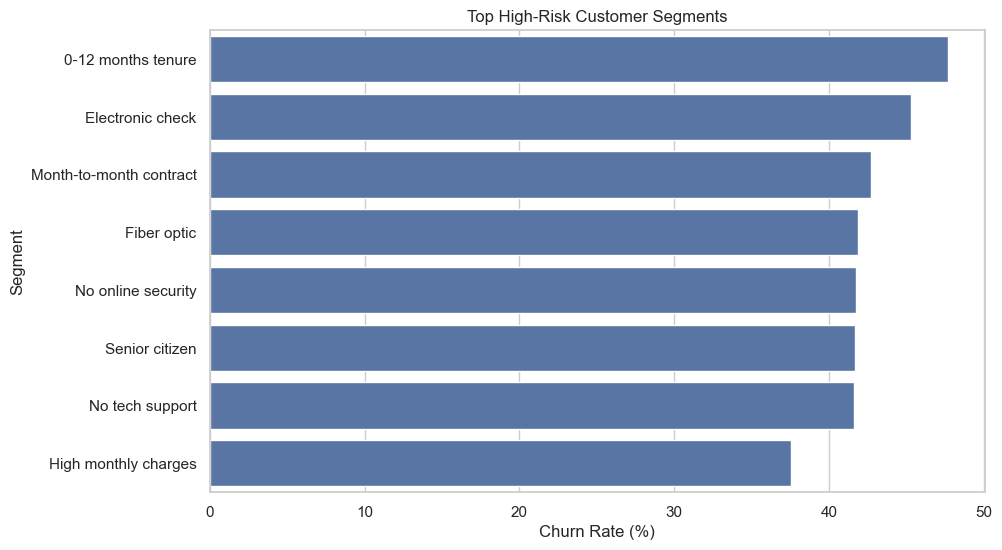

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=risk_summary, y="Segment", x="Churn Rate (%)")
plt.title("Top High-Risk Customer Segments")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Segment")
plt.show()

The highest-risk segments are concentrated among:

- customers in the first 12 months
- month-to-month contract customers
- electronic check users
- fiber optic customers
- customers without support/security add-ons

These groups should be prioritized for retention actions.

## Key Business Insights

Based on the analysis, the main churn drivers appear to be:

1. **Low commitment structure**  
   Month-to-month contracts are associated with much higher churn.

2. **Early customer lifecycle risk**  
   Customers in the first year are the most likely to leave.

3. **Billing and payment behavior**  
   Electronic check and paperless billing segments show higher churn.

4. **Service bundle value**  
   Customers without online security or tech support churn more.

5. **Price-related pressure**  
   Customers with higher monthly charges are more likely to churn.

## Business Recommendations

Based on these results, the company could consider the following retention strategies:

- Encourage migration from month-to-month plans to longer-term contracts
- Strengthen onboarding during the first 12 months
- Promote automatic payment methods
- Offer retention bundles that include online security and tech support
- Review pricing and perceived value for high-charge customer groups
- Create targeted campaigns for high-risk segments such as fiber optic users and senior customers

## Conclusion

This analysis shows that churn is not random.

Customers with short-term contracts, short tenure, limited support services, and certain billing behaviors are significantly more likely to leave.

From a business perspective, retention efforts should focus on the earliest stage of the customer journey and on high-risk service and billing segments.

The next step is to complement this business analysis with a financial analysis to estimate the revenue impact of churn.